In [35]:
import pandas as pd
import pyreadstat

# Replace 'your_file.sav' with the path to your .sav file
file_path_ABSENTEE = 'data/ABSENTEE.SAV'
file_path_BatchId = 'data/BatchId.sav'
file_path_DEATH = 'data/DEATH.SAV'
file_path_Household = 'data/Household.SAV'
file_path_Individual01 = 'data/Individual01.SAV'
file_path_Individual02 = 'data/Individual02.SAV'

Absentee, meta1 = pyreadstat.read_sav(file_path_ABSENTEE)
BatchId, meta2 = pyreadstat.read_sav(file_path_BatchId)
Death, meta3 = pyreadstat.read_sav(file_path_DEATH)
Household, meta4 = pyreadstat.read_sav(file_path_Household)
Individual01, meta5 = pyreadstat.read_sav(file_path_Individual01)
Individual02, meta6 = pyreadstat.read_sav(file_path_Individual02)

"""df1.to_csv("ABSENTEE.csv", index=False)
   df2.to_csv("BatchId.csv", index=False)
   df3.to_csv("DEATH.csv", index=False)
   df4.to_csv("Household.csv", index=False)
   df5.to_csv("Individual01.csv", index=False)
   df6.to_csv("Individual02.csv", index=False)"""

'df1.to_csv("ABSENTEE.csv", index=False)\n   df2.to_csv("BatchId.csv", index=False)\n   df3.to_csv("DEATH.csv", index=False)\n   df4.to_csv("Household.csv", index=False)\n   df5.to_csv("Individual01.csv", index=False)\n   df6.to_csv("Individual02.csv", index=False)'

In [36]:
print("Death")
Death.shape

Death


(20934, 9)

In [37]:
print("Columns:\n", Death.columns.tolist())  # Lists all column names
print("Number of columns:",len(Death.columns))  # Counts the number of columns


Columns:
 ['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H12IDC', 'H12SEX', 'H12AGE']
Number of columns: 9


In [38]:
Death.head(10)

,DIST,VDCMUN,WARD,EA,HNO,HHNO,H12IDC,H12SEX,H12AGE
0,1.0,1.0,1.0,0.0,37.0,37.0,1.0,2.0,72.0
1,1.0,1.0,4.0,0.0,26.0,27.0,1.0,1.0,4.0
2,1.0,1.0,5.0,0.0,4.0,4.0,1.0,2.0,60.0
3,1.0,2.0,9.0,0.0,7.0,7.0,1.0,2.0,52.0
4,1.0,3.0,8.0,0.0,10.0,10.0,1.0,2.0,75.0
5,1.0,4.0,1.0,0.0,5.0,5.0,1.0,2.0,50.0
6,1.0,4.0,3.0,0.0,27.0,27.0,1.0,1.0,1.0
7,1.0,4.0,3.0,0.0,35.0,35.0,1.0,1.0,48.0
8,1.0,4.0,5.0,0.0,67.0,70.0,1.0,1.0,51.0
9,1.0,4.0,6.0,0.0,76.0,77.0,1.0,2.0,71.0


# Data cleaning

In [39]:
# Handling missing values and duplicates
print("Missing Values Per Column:\n")
print(Death.isnull().sum())
print("\nNumber of Duplicate Rows:", Death.duplicated().sum())

Missing Values Per Column:

DIST      0
VDCMUN    0
WARD      0
EA        0
HNO       0
HHNO      0
H12IDC    0
H12SEX    0
H12AGE    0
dtype: int64

Number of Duplicate Rows: 0


In [40]:
# View invalid age rows
invalid_ages = Death[(Death['H12AGE'] < 0) | (Death['H12AGE'] > 120)]

# Display them
print(invalid_ages)


       DIST  VDCMUN  WARD   EA    HNO   HHNO  H12IDC  H12SEX  H12AGE
36      1.0    15.0   3.0  0.0   24.0   24.0     1.0     1.0   999.0
45      1.0    19.0   3.0  0.0   14.0   14.0     1.0     1.0   999.0
121     2.0     5.0   8.0  0.0   35.0   36.0     1.0     2.0   999.0
136     2.0    11.0   8.0  0.0    3.0    3.0     1.0     2.0   999.0
175     2.0    23.0   5.0  0.0   66.0   66.0     1.0     2.0   999.0
...     ...     ...   ...  ...    ...    ...     ...     ...     ...
20779  74.0    41.0   9.0  0.0  107.0  119.0     1.0     2.0   999.0
20800  74.0    48.0   3.0  0.0   26.0   29.0     1.0     1.0   999.0
20853  75.0    11.0   1.0  0.0   19.0  258.0     1.0     1.0   999.0
20901  75.0    27.0   5.0  0.0   18.0   21.0     1.0     1.0   999.0
20926  75.0    35.0   2.0  0.0   47.0   48.0     1.0     1.0   999.0

[504 rows x 9 columns]


In [41]:
# Drop rows with invalid age (< 0 or > 120)
Death_cleaned = Death[(Death['H12AGE'] >= 0) & (Death['H12AGE'] <= 120)].copy()

# Check how many rows remain
print(f"Remaining rows after dropping invalid ages: {Death_cleaned.shape[0]}")


Remaining rows after dropping invalid ages: 20430


### Extracting and Applying Metadata (Labels and Descriptions)

In [42]:
print(meta3.column_names)
print(meta3.column_labels)

['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H12IDC', 'H12SEX', 'H12AGE']
['District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 'House no.', 'Household no.', '12. ID code of decease person', '12. Sex of decease person', '12. Age of dead person']


In [43]:
# Get value labels for categorical variables
print(meta3.value_labels)

{'labels0': {1.0: 'Taplejung', 2.0: 'Panchthar', 3.0: 'Ilam', 4.0: 'Jhapa', 5.0: 'Morang', 6.0: 'Sunsari', 7.0: 'Dhankuta', 8.0: 'Terhathum', 9.0: 'Sankhuwasabha', 10.0: 'Bhojpur', 11.0: 'Solukhumbu', 12.0: 'Okhaldhunga', 13.0: 'Khotang', 14.0: 'Udayapur', 15.0: 'Saptari', 16.0: 'Siraha', 17.0: 'Dhanusa', 18.0: 'Mahottari', 19.0: 'Sarlahi', 20.0: 'Sindhuli', 21.0: 'Ramechhap', 22.0: 'Dolakha', 23.0: 'Sindhupalchok', 24.0: 'Kavrepalanchok', 25.0: 'Lalitpur', 26.0: 'Bhaktapur', 27.0: 'Kathmandu', 28.0: 'Nuwakot', 29.0: 'Rasuwa', 30.0: 'Dhading', 31.0: 'Makwanpur', 32.0: 'Rautahat', 33.0: 'Bara', 34.0: 'Parsa', 35.0: 'Chitawan', 36.0: 'Gorkha', 37.0: 'Lamjung', 38.0: 'Tanahu', 39.0: 'Syangja', 40.0: 'Kaski', 41.0: 'Manang', 42.0: 'Mustang', 43.0: 'Myagdi', 44.0: 'Parbat', 45.0: 'Baglung', 46.0: 'Gulmi', 47.0: 'Palpa', 48.0: 'Nawalparasi', 49.0: 'Rupandehi', 50.0: 'Kapilbastu', 51.0: 'Arghakhanchi', 52.0: 'Pyuthan', 53.0: 'Rolpa', 54.0: 'Rukum', 55.0: 'Salyan', 56.0: 'Dang', 57.0: 'Banke',

### Rename columns in the DataFrame using metadata

In [44]:
# Rename column mapping
col_names = ['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H12IDC', 'H12SEX', 'H12AGE']
col_labels = ['District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 
              'House no.', 'Household no.', '12. ID code of deceased person', 
              '12. Sex of deceased person', '12. Age of dead person']

# Apply renaming
Death.rename(columns=dict(zip(col_names, col_labels)), inplace=True)


In [45]:
Death.head(5)

,District,V.D.C./Municipality,Ward no.,Enumeration area,House no.,Household no.,12. ID code of deceased person,12. Sex of deceased person,12. Age of dead person
0,1.0,1.0,1.0,0.0,37.0,37.0,1.0,2.0,72.0
1,1.0,1.0,4.0,0.0,26.0,27.0,1.0,1.0,4.0
2,1.0,1.0,5.0,0.0,4.0,4.0,1.0,2.0,60.0
3,1.0,2.0,9.0,0.0,7.0,7.0,1.0,2.0,52.0
4,1.0,3.0,8.0,0.0,10.0,10.0,1.0,2.0,75.0


In [46]:
# Mapping value labels from metadata to the Household DataFrame
label_mapping = {
    'labels0': 'District',
    'labels1': 'Sex of deceased person',
    'labels2': 'Age of dead person'
}

# Apply mappings
for label_key, col_name in label_mapping.items():
    if label_key in meta3.value_labels and col_name in Death.columns:
        Death[col_name] = Death[col_name].map(meta3.value_labels[label_key])


In [47]:
Death.head(5)

,District,V.D.C./Municipality,Ward no.,Enumeration area,House no.,Household no.,12. ID code of deceased person,12. Sex of deceased person,12. Age of dead person
0,Taplejung,1.0,1.0,0.0,37.0,37.0,1.0,2.0,72.0
1,Taplejung,1.0,4.0,0.0,26.0,27.0,1.0,1.0,4.0
2,Taplejung,1.0,5.0,0.0,4.0,4.0,1.0,2.0,60.0
3,Taplejung,2.0,9.0,0.0,7.0,7.0,1.0,2.0,52.0
4,Taplejung,3.0,8.0,0.0,10.0,10.0,1.0,2.0,75.0


# Descriptive Analysis

(Summarize and describe the data)

Count total deaths in the dataset.

Gender distribution of deceased persons: Male vs Female count & percentage.

In [48]:

# Total deaths
total_deaths = Death.shape[0]
print(f"Total deaths recorded: {total_deaths}")

Total deaths recorded: 20934


### Deaths by District


Deaths by District:
 District
Kathmandu     1122
Jhapa          682
Morang         661
Rupandehi      614
Sunsari        613
              ... 
Jumla           84
Solukhumbu      76
Myagdi          71
Mustang         70
Manang          36
Name: count, Length: 75, dtype: int64


C:\Users\sagun\AppData\Local\Temp\ipykernel_7292\3828275275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deaths_by_district.index, y=deaths_by_district.values, palette='viridis')


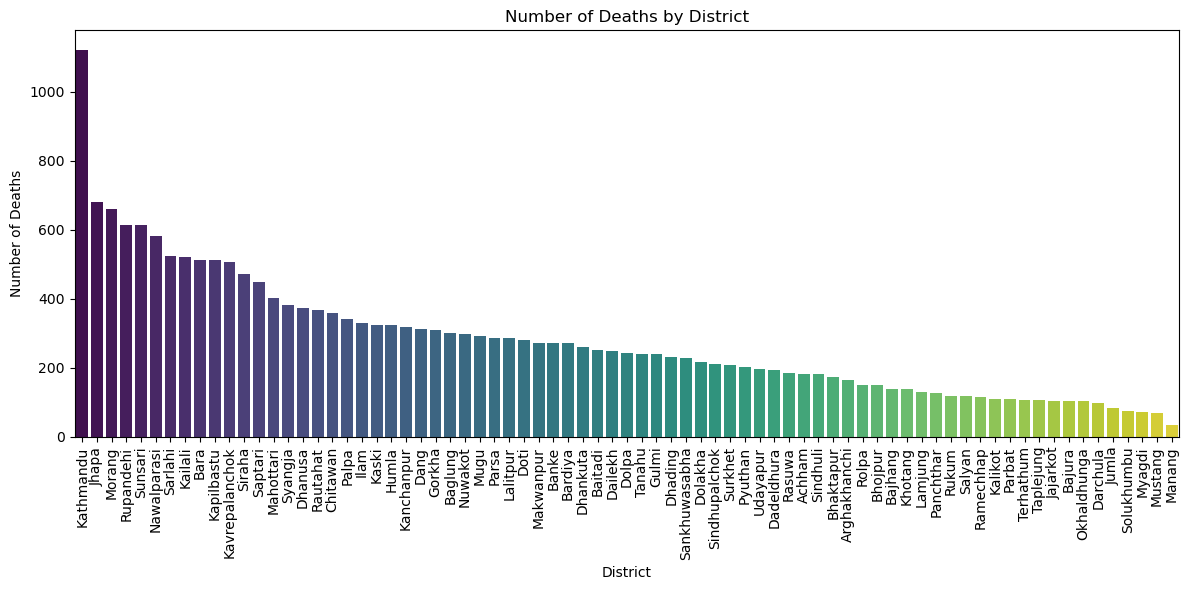

In [49]:
# Deaths by District
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
deaths_by_district = Death['District'].value_counts().sort_values(ascending=False)
print("\nDeaths by District:\n", deaths_by_district)

plt.figure(figsize=(12,6))
sns.barplot(x=deaths_by_district.index, y=deaths_by_district.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Number of Deaths by District')
plt.xlabel('District')
plt.ylabel('Number of Deaths')
plt.tight_layout()
plt.show()

### # Age distribution statistics


Age distribution statistics:
 count    20934.000000
mean        75.445400
std        147.770897
min          0.000000
25%         34.000000
50%         61.000000
75%         76.000000
max        999.000000
Name: 12. Age of dead person, dtype: float64

Death counts by Age Group:
 Age Group
Child (0-14)      1591
Adult (15-59)     6101
Elderly (60+)    11013
Name: count, dtype: int64


C:\Users\sagun\AppData\Local\Temp\ipykernel_7292\2617359545.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='coolwarm')


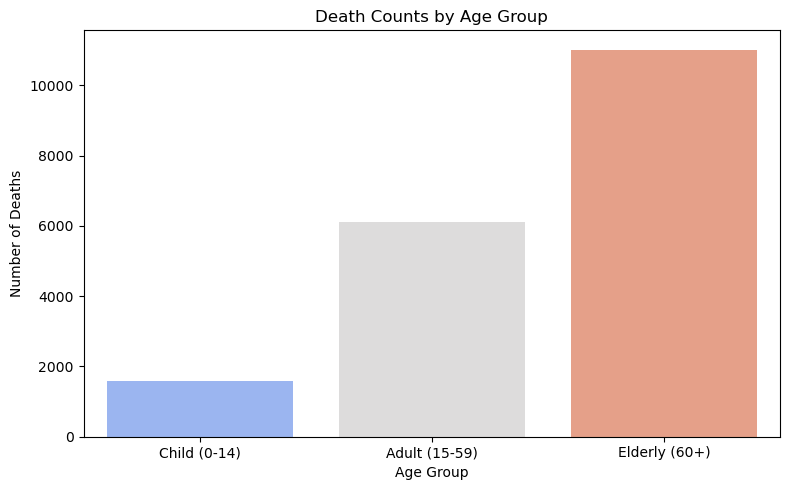

In [50]:
# Age distribution statistics
age_stats = Death['12. Age of dead person'].describe()
print("\nAge distribution statistics:\n", age_stats)

# Create age groups: child (0-14), adult (15-59), elderly (60+)
bins = [0, 14, 59, 120]
labels = ['Child (0-14)', 'Adult (15-59)', 'Elderly (60+)']
Death['Age Group'] = pd.cut(Death['12. Age of dead person'], bins=bins, labels=labels, right=True)

age_group_counts = Death['Age Group'].value_counts().sort_index()
print("\nDeath counts by Age Group:\n", age_group_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='coolwarm')
plt.title('Death Counts by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Deaths')
plt.tight_layout()
plt.show()

### #Gender distribution



Gender distribution of deceased persons:
 12. Sex of deceased person
Male          11696
Female         9003
Not Stated      235
Name: count, dtype: int64


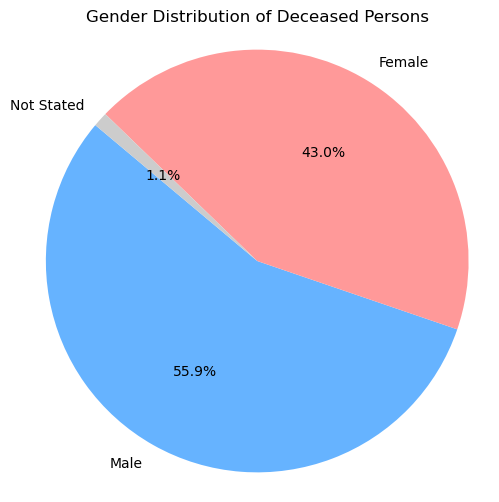

In [51]:
# Map gender codes to labels
gender_map = {1.0: 'Male', 2.0: 'Female', 9.0: 'Not Stated'}
Death['12. Sex of deceased person'] = Death['12. Sex of deceased person'].map(gender_map)

# Count after mapping
gender_counts = Death['12. Sex of deceased person'].value_counts()

print("\nGender distribution of deceased persons:\n", gender_counts)

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999', '#cccccc'])
plt.title('Gender Distribution of Deceased Persons')
plt.axis('equal')
plt.show()


### MOrtality rate

In [52]:
# Total deaths
total_deaths = Death.shape[0]

# Assuming you have total population from Individual dataset
total_population = 26494504

mortality_rate_per_1000 = (total_deaths / total_population) * 1000

print(f"Total Deaths: {total_deaths}")
print(f"Total Population: {total_population}")
print(f"Mortality Rate per 1000 population: {mortality_rate_per_1000:.2f}")


Total Deaths: 20934
Total Population: 26494504
Mortality Rate per 1000 population: 0.79


 ### Deaths by district and age group

C:\Users\sagun\AppData\Local\Temp\ipykernel_7292\2874535159.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_district = Death.groupby(['District', 'Age Group']).size().reset_index(name='Count')


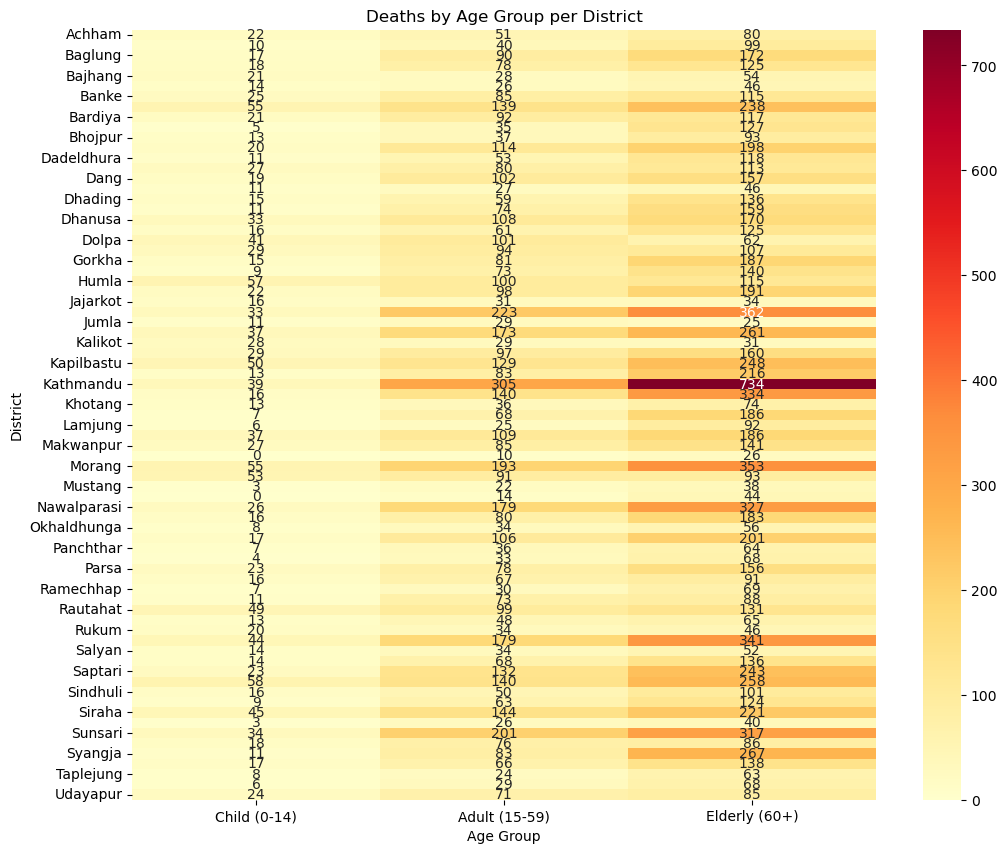

In [53]:
# Group deaths by district and age group
age_district = Death.groupby(['District', 'Age Group']).size().reset_index(name='Count')

# Pivot for heatmap
age_district_pivot = age_district.pivot(index='District', columns='Age Group', values='Count').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(age_district_pivot, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Deaths by Age Group per District')
plt.show()


###  District-wise Mortality Rate (using Household data for population denominator) 
### Integration of Death and household

In [62]:
col_names = [
    'DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H01', 'H021', 'H022', 'H023', 'H024', 'H025',
    'H03', 'H04', 'H05', 'H06', 'H07A', 'H07B', 'H07C', 'H07D', 'H07E', 'H07F', 'H07G', 'H07H',
    'H07I', 'H07J', 'H07K', 'H07L', 'H08', 'H09', 'H10B', 'H10K', 'H10D', 'H10R', 'H10A', 'H10P',
    'H11', 'H11NO', 'H13', 'H13NO'
]

col_labels = [
    'District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 'House no.', 'Household no.',
    'Q.1  Type of the house ownership', 'Q.2.1 Type of foundation of the house',
    'Q.2.2 Type of outer wall of the house', 'Q.2.3 Type of roof of the house', 'Q.2.4 No. of floor',
    'Q.2.5 Year of construction', 'Q.3 Main source of drinking water',
    'Q.4 Usual type of fuel used for cooking', 'Q.5 Usual source of lighting',
    'Q.6 Type of toilet used', 'Q.7.Household amenities - 1', 'Q.7 Household amenities - 2',
    'Q.7 Household amenities - 3', 'Q.7 Household amenities - 4', 'Q.7 Household amenities - 5',
    'Q.7 Household amenities - 6', 'Q.7 Household amenities - 7', 'Q.7 Household amenities - 8',
    'Q.7 Household amenities - 9', 'Q.7 Household amenities - 10', 'Q.7 Household amenities - 11',
    'Q.7 Household amenities - 12', 'Q.8 Having female ownership in house',
    'Q.9 Having female ownership in land', 'Q.10 Area of land on female ownership   - Bigha',
    'Q.10 Area of land on female ownership -  Kattha', 'Q.10 Area of land on female ownership - Dhur',
    'Q.10 Area of land on female ownership - Ropani', 'Q.10 Area of land on female ownership - Aana',
    'Q.10 Area of land on female ownership - Paisa', 'Q.11 Having death during the past 12 months',
    'Q.11 If yes, no. of dead person', 'Q.13 Having person absent (abroad) from household',
    'Total absent member (abroad)'
]
# Create a dictionary mapping short codes to full question labels
rename_dict = dict(zip(col_names, col_labels))

# Rename columns in the Household DataFrame
Household.rename(columns=rename_dict, inplace=True)


# Mapping value labels from metadata to the Household DataFrame
label_mapping = {
    'labels0': 'District',
    'labels1': 'Q.1  Type of the house ownership',
    'labels2': 'Q.2.1 Type of foundation of the house',
    'labels3': 'Q.2.2 Type of outer wall of the house',
    'labels4': 'Q.2.3 Type of roof of the house',
    'labels5': 'Q.2.4 No. of floor',
    'labels6': 'Q.2.5 Year of construction',
    'labels7': 'Q.3 Main source of drinking water',
    'labels8': 'Q.4 Usual type of fuel used for cooking',
    'labels9': 'Q.5 Usual source of lighting',
    'labels10': 'Q.6 Type of toilet used',
    'labels11': 'Q.7.Household amenities - 1',
    'labels12': 'Q.7 Household amenities - 2',
    'labels13': 'Q.8 Having female ownership in house',
    'labels14': 'Q.9 Having female ownership in land'
}

# Apply mappings
for label_key, col_name in label_mapping.items():
    if label_key in meta4.value_labels and col_name in Household.columns:
        Household[col_name] = Household[col_name].map(meta4.value_labels[label_key])

# Calculate missing ratio per column
missing_ratio = Household.isna().mean()

# Keep columns where missing ratio is less than a threshold (say 5%), or the column is "Having female ownership in land"
columns_to_keep = missing_ratio[(missing_ratio < 0.05) | (missing_ratio.index == 'Having female ownership in land')].index

# Filter the dataframe with these columns only
Household_cleaned = Household[columns_to_keep].copy()

print(f"Columns retained: {list(columns_to_keep)}")
print(f"Shape after dropping columns: {Household_cleaned.shape}")


Columns retained: ['District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 'House no.', 'Household no.', 'Q.1  Type of the house ownership', 'Q.2.1 Type of foundation of the house', 'Q.2.2 Type of outer wall of the house', 'Q.2.3 Type of roof of the house', 'Q.3 Main source of drinking water', 'Q.4 Usual type of fuel used for cooking', 'Q.5 Usual source of lighting', 'Q.6 Type of toilet used', 'Q.7.Household amenities - 1', 'Q.8 Having female ownership in house', 'Q.9 Having female ownership in land', 'Q.11 Having death during the past 12 months', 'Q.13 Having person absent (abroad) from household']
Shape after dropping columns: (841567, 19)


In [63]:
Household_cleaned.head(5)

,District,V.D.C./Municipality,Ward no.,Enumeration area,House no.,Household no.,Q.1 Type of the house ownership,Q.2.1 Type of foundation of the house,Q.2.2 Type of outer wall of the house,Q.2.3 Type of roof of the house,Q.3 Main source of drinking water,Q.4 Usual type of fuel used for cooking,Q.5 Usual source of lighting,Q.6 Type of toilet used,Q.7.Household amenities - 1,Q.8 Having female ownership in house,Q.9 Having female ownership in land,Q.11 Having death during the past 12 months,Q.13 Having person absent (abroad) from household
0,Taplejung,1.0,1.0,0.0,13.0,13.0,Own,Mud bonded bricks/stone,Mud bonded bricks/stone,Galvanized iron,Tap/piped,Wood / firewood,Solar,Flush toilet (septic tank),Radio,No,No,2.0,2.0
1,Taplejung,1.0,1.0,0.0,21.0,21.0,Own,Mud bonded bricks/stone,Mud bonded bricks/stone,Galvanized iron,Tap/piped,Wood / firewood,Solar,Flush toilet (septic tank),Radio,No,Yes,2.0,2.0
2,Taplejung,1.0,1.0,0.0,29.0,29.0,Rented,Mud bonded bricks/stone,Mud bonded bricks/stone,Galvanized iron,Tap/piped,Wood / firewood,Solar,Ordinary toilet,Computer,No,No,2.0,1.0
3,Taplejung,1.0,1.0,0.0,37.0,37.0,Own,Mud bonded bricks/stone,Mud bonded bricks/stone,Thatch / straw,Tap/piped,Wood / firewood,Solar,Flush toilet (septic tank),Radio,No,No,1.0,2.0
4,Taplejung,1.0,1.0,0.0,45.0,45.0,Own,Mud bonded bricks/stone,Mud bonded bricks/stone,Thatch / straw,Tap/piped,Wood / firewood,Solar,No toilet,Radio,No,No,2.0,2.0


     District  Death Count  Household Count  Mortality Rate per 100 Households
30    Kalikot          110             2845                           3.866432
73  Terhathum          107             2785                           3.842011
28      Jumla           84             2399                           3.501459
53    Pyuthan          204             5922                           3.444782
24      Humla          324             9427                           3.436936
..        ...          ...              ...                                ...
45     Myagdi           71             3506                           2.025100
19    Dolakha          218            10981                           1.985247
22     Gorkha          310            15966                           1.941626
55     Rasuwa          185             9741                           1.899189
66     Siraha          472            25113                           1.879505

[75 rows x 4 columns]


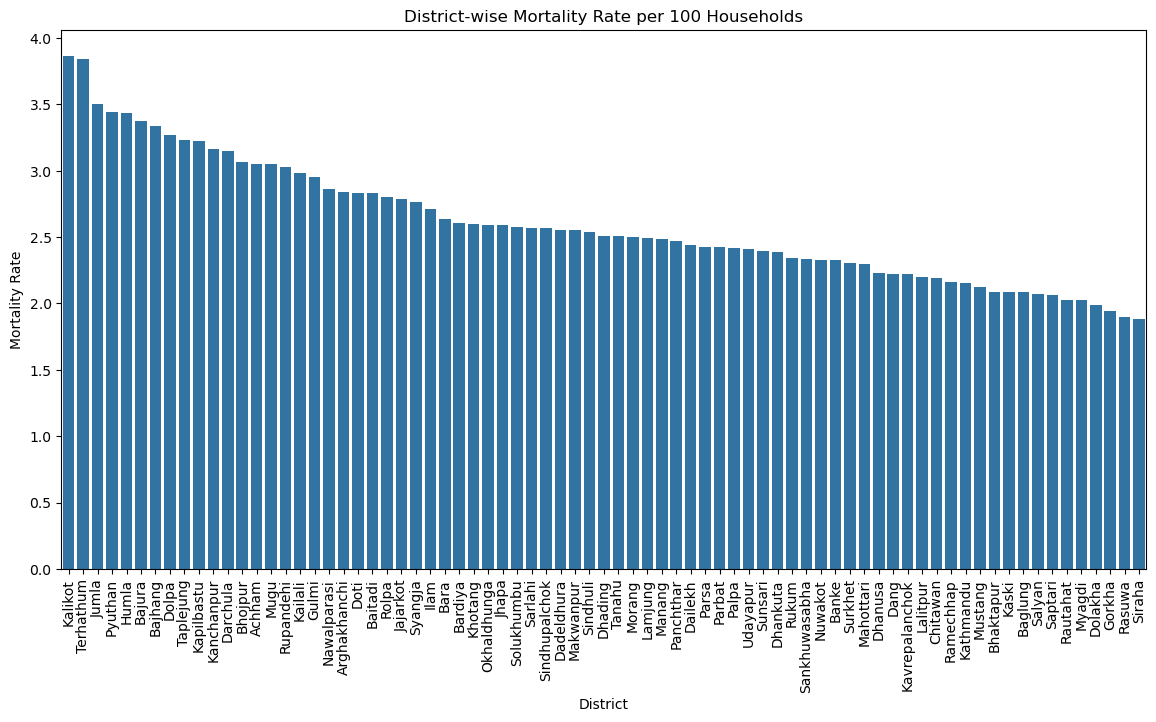

In [65]:
# Count deaths per district
deaths_per_district = Death.groupby('District').size().reset_index(name='Death Count')

# Assuming you have total households or population per district in Household dataset
households_per_district = Household_cleaned.groupby('District').size().reset_index(name='Household Count')

# Merge both
district_mortality = pd.merge(deaths_per_district, households_per_district, on='District', how='left')

# Calculate mortality rate per 100 households
district_mortality['Mortality Rate per 100 Households'] = (district_mortality['Death Count'] / district_mortality['Household Count']) * 100

# Sort and display
district_mortality = district_mortality.sort_values('Mortality Rate per 100 Households', ascending=False)
print(district_mortality)

# Plot
plt.figure(figsize=(14,7))
sns.barplot(data=district_mortality, x='District', y='Mortality Rate per 100 Households')
plt.xticks(rotation=90)
plt.title('District-wise Mortality Rate per 100 Households')
plt.ylabel('Mortality Rate')
plt.show()
